In [40]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import (
    chi2_contingency,
    ttest_ind,
    shapiro,
    mannwhitneyu
)

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler,
    MinMaxScaler,
    RobustScaler
)

In [41]:
import pandas as pd

df = pd.read_csv(r'C:\Users\Nina\OneDrive\Desktop\marketing_AB.csv')

# Viewing Data

In [3]:
df.head()

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


In [4]:
df.shape

(588101, 7)

In [5]:
df.columns

Index(['Unnamed: 0', 'user id', 'test group', 'converted', 'total ads',
       'most ads day', 'most ads hour'],
      dtype='object')

In [6]:
df.info

<bound method DataFrame.info of         Unnamed: 0  user id test group  converted  total ads most ads day  \
0                0  1069124         ad      False        130       Monday   
1                1  1119715         ad      False         93      Tuesday   
2                2  1144181         ad      False         21      Tuesday   
3                3  1435133         ad      False        355      Tuesday   
4                4  1015700         ad      False        276       Friday   
...            ...      ...        ...        ...        ...          ...   
588096      588096  1278437         ad      False          1      Tuesday   
588097      588097  1327975         ad      False          1      Tuesday   
588098      588098  1038442         ad      False          3      Tuesday   
588099      588099  1496395         ad      False          1      Tuesday   
588100      588100  1237779         ad      False          1      Tuesday   

        most ads hour  
0                  

# Data Cleaning

In [46]:
# Missing Values
df.isnull().sum()

Unnamed: 0       0
user_id          0
test_group       0
converted        0
total_ads        0
most_ads_day     0
most_ads_hour    0
dtype: int64

In [47]:
# Remove Duplicates
df.drop_duplicates(inplace=True)

In [48]:
# Rename Columns
df.columns = ['Unnamed: 0',
    'user_id',
    'test_group',
    'converted',
    'total_ads',
    'most_ads_day',
    'most_ads_hour'
]

# Exploratory Data Analysis

In [49]:
# Statistical Summary
df.describe()

,Unnamed: 0,user_id,total_ads,most_ads_hour
count,588101.000000,5.881010e+05,588101.000000,588101.000000
mean,294050.000000,1.310692e+06,24.820876,14.469061
std,169770.279667,2.022260e+05,43.715181,4.834634
min,0.000000,9.000000e+05,1.000000,0.000000
25%,147025.000000,1.143190e+06,4.000000,11.000000
50%,294050.000000,1.313725e+06,13.000000,14.000000
75%,441075.000000,1.484088e+06,27.000000,18.000000
max,588100.000000,1.654483e+06,2065.000000,23.000000


# Data Visualization

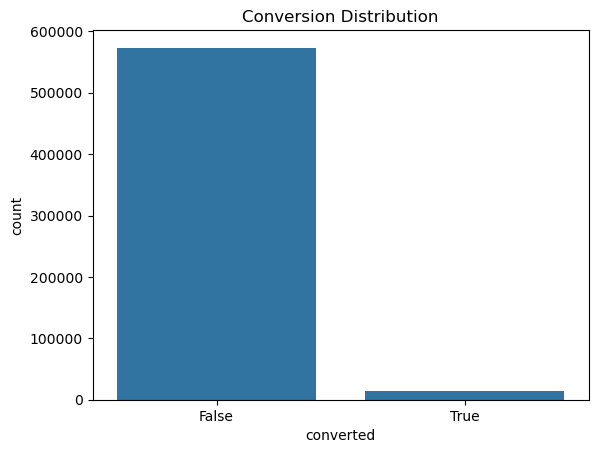

In [12]:
# Conversion Distribution
sns.countplot(x='converted', data=df)
plt.title('Conversion Distribution')
plt.show()

In [19]:
# NOTE: Chart shows number of people who converted into customers after watching ADS as True and those who didn't as False

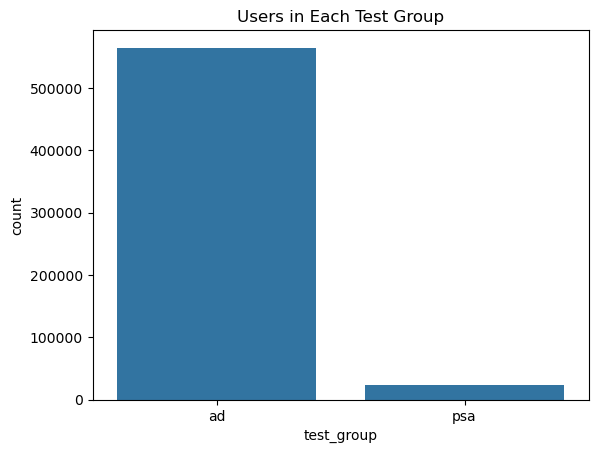

In [13]:
# Users in Each Group
sns.countplot(x='test_group', data=df)
plt.title('Users in Each Test Group')
plt.show()

In [21]:
# Chart shows numbers of users who watched ADS under "ad" and those who didn't watch AD as "psa"

In [31]:
# CONVERSION RATE ANALYSIS
conversion_rate = df.groupby(
    'test_group'
)['converted'].mean()
print(conversion_rate)

test_group
ad     0.025547
psa    0.017854
Name: converted, dtype: float64


In [23]:
# Note: Above shows those who converted into customers after seeing the ad as 0.0255, which is 2.55%

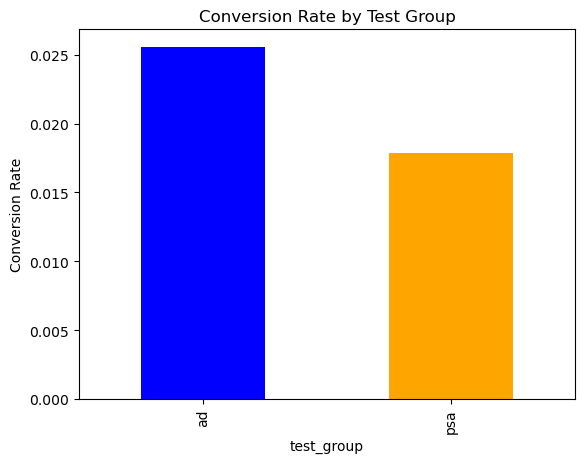

In [32]:
# VISUALIZE CONVERSION RATE
conversion_rate.plot(
    kind='bar',
    color=['blue', 'orange']
)
plt.ylabel('Conversion Rate')
plt.title('Conversion Rate by Test Group')
plt.show()

# CHI SQUARE TEST

In [26]:
# Why CHI-Square Test? 1. Converted is categorical 2. Comparing proportions between groups 

In [50]:
# Create Contingency Table
contingency_table = pd.crosstab(
    df['test_group'],
    df['converted']
)
print(contingency_table)

converted    False  True 
test_group               
ad          550154  14423
psa          23104    420


In [29]:
# Note: This gives a Table of how many in each test group were converted as True and how many weren't as False

In [51]:
# Run Chi-Square Test
chi2, p, dof, expected = chi2_contingency(
    contingency_table
)
print("Chi-Square Statistic:", chi2)
print("P-value:", p)

Chi-Square Statistic: 54.005823883685245
P-value: 1.9989623063390075e-13


In [ ]:
# P-Value is  1.9989623063390075e-13, which is below 0 because it is -13 at the right of the value

In [35]:
# Interpretation
alpha = 0.05

if p < alpha:

    print("Reject Null Hypothesis")

else:

    print("Fail to Reject Null Hypothesis")

Reject Null Hypothesis


In [ ]:
# Note: Reject Null Hypothesis means there is a difference.  Ads do make a difference in customers converting to customers.

In [36]:
# Interpretation
alpha = 0.05
if p < alpha:
    print("Conclusion: Statistically significant! The groups perform differently.")
else:
    print("Conclusion: Not statistically significant. No evidence of a difference.")

Conclusion: Statistically significant! The groups perform differently.


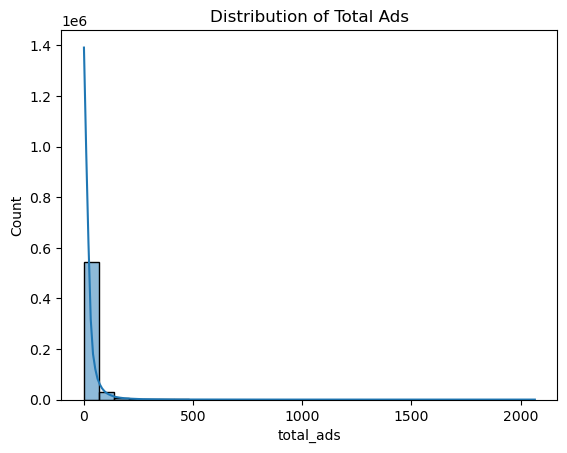

In [24]:
# DISTRIBUTION OF TOTAL ADS
sns.histplot(
    df['total_ads'],
    bins=30,
    kde=True
)

plt.title('Distribution of Total Ads')
plt.show()

In [37]:
# Above Histogram shows Right skewed, shape and distribution. The total number of ads < 500 in bins between 0 and 250. 
# Number of users/watchers is 1.4 (hundreds or thousands)

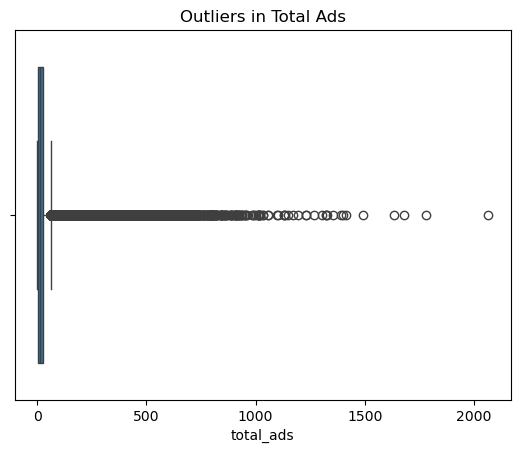

In [37]:
# BOXPLOT FOR OUTLIERS, Shows Extreme Values ie. Outliers
sns.boxplot(x=df['total_ads'])

plt.title('Outliers in Total Ads')

plt.show()

In [52]:
# # IQR OUTLIER DETECTION

# Calculate Quartiles

Q1 = df['total_ads'].quantile(0.25)
Q3 = df['total_ads'].quantile(0.75)
IQR = Q3 - Q1

# Calculate Bounds

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Print the results to see the actual numbers
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Lower Bound: -30.5
Upper Bound: 61.5


In [55]:
# Detect Outliers
outliers = df[
    (df['total_ads'] < lower_bound) |
    (df['total_ads'] > upper_bound)
]

In [ ]:
# Note: Outliers were removed earlier

In [56]:
# Remove Outliers
df_clean = df[
    (df['total_ads'] >= lower_bound) &
    (df['total_ads'] <= upper_bound)
]

In [58]:
# NORMALITY TEST # Checks if data follows normal distribution
sample_data = df_clean[
    'total_ads'
].sample(5000)

stat, p = shapiro(sample_data)

print(p)

1.6088930398597635e-54


In [ ]:
# Data is not Normal

In [59]:
# Interpretation
if p > 0.05:
    print("Normal Distribution")
else:
    print("Not Normal")

Not Normal


In [78]:
from scipy.stats import mannwhitneyu

# 1. Define the groups using the 'test group' column
# (Assuming you are testing the difference in 'total ads' between groups)
ad_group = df[df['test_group'] == 'ad']['total_ads']
psa_group = df[df['test_group'] == 'psa']['total_ads']

# 2. Run the Mann-Whitney U test
u_stat, p = mannwhitneyu(ad_group, psa_group)

# 3. Print the results
print(f"U-statistic: {u_stat}")
print(f"p-value: {p}")

U-statistic: 6808288222.0
p-value: 4.6909108547205694e-11


In [63]:
# Note: Import Mann Whitney Library
# We have to use the above code to separate ad group from pca group mentioned in test group combined
# P Value is minus 11 so Null Hypothesis is not True, meaning there is a difference or ADS do convert customers in this case

In [68]:
# — DAY ANALYSIS
day_conversion = df.groupby(
    'most_ads_day'
)['converted'].mean()

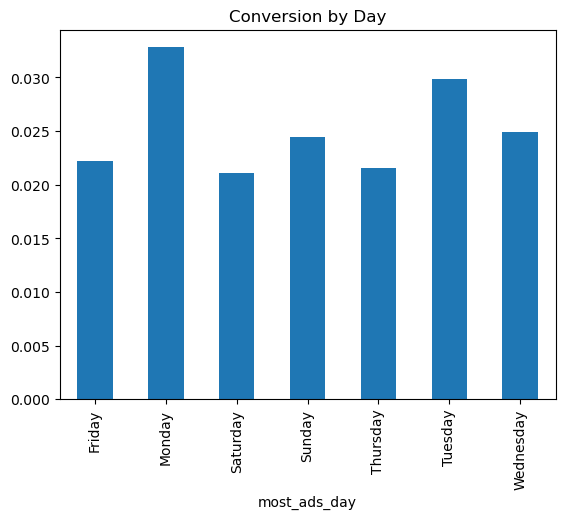

In [69]:
# Visualization
day_conversion.plot(kind='bar')

plt.title('Conversion by Day')

plt.show()

In [70]:
# Chart shows Monday, Tesuday and Wednesdays where the ads resulted in most viewers to convert into customers

In [71]:
# HOUR ANALYSIS
hour_conversion = df.groupby(
    'most_ads_hour'
)['converted'].mean()

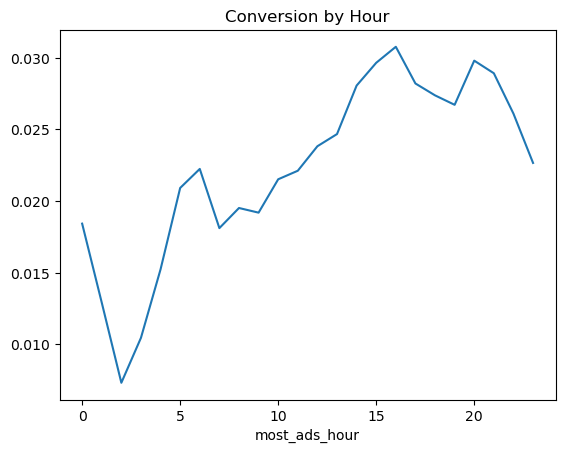

In [72]:
# Visualization
hour_conversion.plot()

plt.title('Conversion by Hour')

plt.show()

In [73]:
# Chart shows the hours or time at which there were most conversions, peak conversion at 15 hours ie 3 p.m. and 20 hours ie 8 p.m.

In [85]:
print(df.columns)

Index(['Unnamed: 0', 'user_id', 'converted', 'total_ads', 'most_ads_day',
       'most_ads_hour', 'test_group_encoded', 'test_group_ad',
       'test_group_psa'],
      dtype='object')


In [87]:
# Calculate conversion rate for Ad group
ad_conv = df[df['test_group_ad'] == 1]['converted'].mean() * 100

# Calculate conversion rate for PSA group
psa_conv = df[df['test_group_psa'] == 1]['converted'].mean() * 100

print(f"Ad Group Conversion Rate: {ad_conv:.2f}%")
print(f"PSA Group Conversion Rate: {psa_conv:.2f}%")

Ad Group Conversion Rate: 2.55%
PSA Group Conversion Rate: 1.79%


In [ ]:
# Note: Conversion Rate for the group that viewed ads is 2.55% higher than the PSA group, which didn't vie

In [88]:
# Note: Label encoding was done on this data set, so we use test_group_ads and test_group_psa and above code to print conversion rates for each group

# Without label encoding, we need to use the following code to print the conversion rate
# Calculate the conversion rate for each group
# conversion_rates = df.groupby('test_group')['converted'].mean() * 100
# print(conversion_rates)